<a href="https://colab.research.google.com/github/pollyaana/-Desktop-App/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22gensim_model_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pyldavis
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
import pandas as pd
import pyLDAvis
import pyLDAvis.gensim_models
import gzip
import requests
from io import BytesIO
from gensim.models import LdaModel
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Получение токенизированных постов

In [ ]:
filename = 'state_tokens.csv.gz'
response = requests.get(f'https://raw.githubusercontent.com/componavt/sns4human/refs/heads/main/data/vk/posts/tokens/{filename}')
with gzip.GzipFile(fileobj=BytesIO(response.content), mode='rb') as f:
    tokens = pd.read_csv(f, delimiter=',', encoding='utf-8')['tokens']

data = tokens.apply(lambda x: x.split(' ')).tolist()


# Создание мешка слов
Преобразуем документы в векторизованную форму.
Мешок слов (BoW) — это  модель представления текста в виде числового вектора, где:

*    Учитывается наличие слов, но игнорируется их порядок (отсюда "мешок" — слова "перемешаны").

*   Каждому слову ставится в соответствие число (частота или бинарный флаг).




In [ ]:
dictionary = corpora.Dictionary(data)
corpus = [dictionary.doc2bow(text) for text in data]

num_topics = 8

# Тематическое моделирование

In [ ]:
lda_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=15)

topics = [[(term, round(wt, 3))
               for term, wt in lda_model.show_topic(n)]
                   for n in range(0, lda_model.num_topics)]
topics_df = pd.DataFrame([[term for term, wt in topic]
                              for topic in topics],
                         index=['Тема '+str(t) for t in range(1, lda_model.num_topics+1)]).T
topics_df

,Тема 1,Тема 2,Тема 3,Тема 4,Тема 5,Тема 6,Тема 7,Тема 8
0,карелия,карелия,район,коренной,карелия,больница,школа,район
1,республика,карельский,карелия,предприятие,семья,медицинский,детский,сутки
2,национальный,республика,республика,карелия,память,центр,здание,посёлок
3,подробный,культура,рубль,производство,победа,строительство,проект,коронавирус
4,организация,желать,житель,развитие,великий,ремонт,петрозаводск,ситуация
5,проект,язык,бюджет,завод,ребёнок,помощь,спортивный,число
6,карельский,праздник,млн,компания,житель,республиканский,сад,находиться
7,язык,поздравлять,развитие,продукция,акция,оборудование,программа,карелия
8,конкурс,народный,программа,карельский,петрозаводск,карелия,посёлок,республика
9,общественный,коллектив,проект,хозяйство,отечественный,врач,ремонт,петрозаводск


# Оценка

Измерение тематических моделей с помощью связности.
Если тема представляет собой смесь определенных слов, то один из способов измерения семантической связности темы — вычислить совместную встречаемость между словами. То есть, как часто верхние слова в теме встречаются вместе в документах по сравнению с тем, как часто они встречаются независимо.

Оценка тематической модели — сложная тема без четкого количественного подхода, и она до сих пор обсуждается. Более высокая (или более низкая оценка в зависимости от меры) не обязательно означает более высокую качественную модель. То есть оценку, которую человек дал бы, глядя на тематические слова и насколько они интерпретируемы.

# Анализ текущих параметров модели

**Perplexity** — это часто используемая метрика для оценки моделей LDA. Она измеряет, насколько хорошо модель предсказывает новые данные. Более низкий показатель perplexity указывает на лучшую производительность. Вы можете рассчитать perplexity с помощью метода log_perplexity() модели LDA в gensim.

**Интерпретация:**

Низкая перплексия → модель хорошо предсказывает данные.

Высокая перплексия → модель плохо обобщает.

In [ ]:
lda_model.log_perplexity(corpus)    # Чем ближе к 0, тем лучше

-7.9755666732657104

In [ ]:
# Вычислить оценку согласованности
coherence_model_lda = CoherenceModel(model=lda_model, texts=data,
                                     dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('Coherence Score:', coherence_lda)

Coherence Score: 0.580558482119647


# Попробуем повысить оценку

Мы удаляем редкие слова и общие слова на основе их частоты в документах . Ниже мы удаляем слова, которые встречаются менее чем в 20 документах или более чем в 50% документов. Попробуйте удалить слова только на основе их частоты или, может быть, объединить это с этим подходом.

Обрезка низко- и высокочастотных слов.

Одна из вещей, которую мы можем попробовать, — это отфильтровать редкие и распространенные токены.

In [ ]:
# Remove rare and common tokens.
from gensim.corpora import Dictionary

# Create a dictionary representation of the documents.
dictionary = Dictionary(data)

# Отфильтровать слова, которые встречаются менее чем в 20 документах или более чем в 40% документов.
dictionary.filter_extremes(no_below=20, no_above=0.4)
corpus = [dictionary.doc2bow(doc) for doc in data]

lda_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=15)

topics = [[(term, round(wt, 3))
               for term, wt in lda_model.show_topic(n)]
                   for n in range(0, lda_model.num_topics)]
topics_df = pd.DataFrame([[term for term, wt in topic]
                              for topic in topics],
                         index=['Тема '+str(t) for t in range(1, lda_model.num_topics+1)]).T
topics_df

,Тема 1,Тема 2,Тема 3,Тема 4,Тема 5,Тема 6,Тема 7,Тема 8
0,коренной,проект,район,развитие,национальный,акция,школа,поздравлять
1,карельский,организация,сутки,предприятие,карельский,петрозаводск,район,желать
2,периодика,конкурс,посёлок,производство,язык,житель,ремонт,здоровье
3,языковой,глава,ситуация,проект,культура,карельский,программа,праздник
4,издательство,общественный,коронавирус,завод,подробный,церковь,здание,память
5,ресурсный,поддержка,число,регион,общественный,артур,строительство,победа
6,группа,заявка,житель,компания,состояться,страница,детский,казачий
7,инфекция,муниципальный,пациент,правительство,мероприятие,подробный,объект,рождение
8,хозяйство,участие,больница,федеральный,вепсский,православный,средство,великий
9,мера,заседание,медицинский,рабочий,политика,костюм,рубль,отмечать


In [ ]:
lda_model.log_perplexity(corpus)    # Чем ближе к 0, тем лучше

-7.319490678461557

In [ ]:
# Вычислить оценку согласованности
coherence_model_lda = CoherenceModel(model=lda_model, texts=data,
                                     dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('Coherence Score:', coherence_lda)

Coherence Score: 0.6156025572378537


Оценка согласованности повысилась: 0.580558482119647 -> 0.6156025572378537

Фильтрование редких и частотных слов оказалось успешным

Можно найти оптимальное количество тем для LDA, создав множество моделей LDA с различными значениями тем. Среди этих LDA необходимо выбрать одну, имеющую наивысшее значение когерентности.

Функция **compute_coherance_values()** обучает несколько моделей LDA. Она также предоставит модели и соответствующую им оценку когерентности.

In [ ]:
import matplotlib.pyplot as plt

def compute_coherence_values(dictionary, corpus, texts, start=2, limit=50, step=3):
    coherence_values = []
    model_list = []

    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            num_topics=num_topics,
            id2word=dictionary,
            passes=10,
            random_state=42,
            alpha='auto',
            eta='auto'
        )
        model_list.append(model)

        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())

        print(f"Тем: {num_topics}, Когерентность: {coherence_values[-1]:.3f}")

    return model_list, coherence_values

# Вычисление когерентности для разного количества тем
model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=data,
    start=2,
    limit=11,
    step=1
)

Тем: 2, Когерентность: 0.564


Тем: 3, Когерентность: 0.562


Тем: 4, Когерентность: 0.548
Тем: 5, Когерентность: 0.553
Тем: 6, Когерентность: 0.561
Тем: 7, Когерентность: 0.531
Тем: 8, Когерентность: 0.601
Тем: 9, Когерентность: 0.570
Тем: 10, Когерентность: 0.549


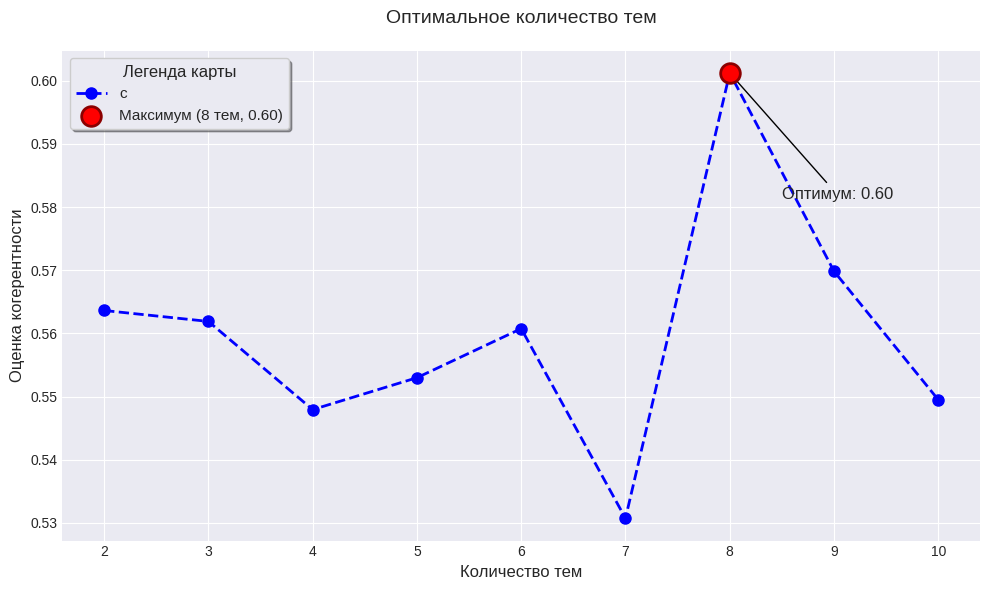

In [ ]:
x = range(2, 11, 1)
max_coherence_idx = coherence_values.index(max(coherence_values))
max_x = x[max_coherence_idx]
max_y = coherence_values[max_coherence_idx]

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6), dpi=100)

plt.plot(
    x,
    coherence_values,
    marker='o',
    markersize=8,
    linestyle='--',
    linewidth=2,
    color='blue',
    label='c'
)

plt.scatter(
    max_x,
    max_y,
    color='red',
    s=200,
    edgecolor='darkred',
    linewidth=2,
    zorder=10,
    label=f'Максимум ({max_x} тем, {max_y:.2f})'
)

plt.annotate(
    f'Оптимум: {max_y:.2f}',
    xy=(max_x, max_y),
    xytext=(max_x + 0.5, max_y - 0.02),
    fontsize=12,
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

plt.title("Оптимальное количество тем", fontsize=14, pad=20)
plt.xlabel("Количество тем", fontsize=12)
plt.ylabel("Оценка когерентности", fontsize=12)
plt.xticks(x)
plt.legend(
    title="Легенда карты",
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()

In [ ]:
for m, cv in zip(x, coherence_values):
   print("Num Topics =", m, " is having Coherence Value of", round(cv, 4))

Num Topics = 2  is having Coherence Value of 0.5636
Num Topics = 3  is having Coherence Value of 0.5619
Num Topics = 4  is having Coherence Value of 0.5479
Num Topics = 5  is having Coherence Value of 0.553
Num Topics = 6  is having Coherence Value of 0.5608
Num Topics = 7  is having Coherence Value of 0.5307
Num Topics = 8  is having Coherence Value of 0.6012
Num Topics = 9  is having Coherence Value of 0.5698
Num Topics = 10  is having Coherence Value of 0.5495


In [ ]:
def compute_coherence_values(corpus, dictionary, k):
    lda_model = LdaModel(corpus=corpus, num_topics=k,
                                id2word=dictionary, passes=10,
                                per_word_topics=True, random_state=42)
    coherence_model_lda = CoherenceModel(model=lda_model,
                                         texts=data,
                                         dictionary=dictionary, coherence='c_v')
    return coherence_model_lda.get_coherence()

import numpy as np
from tqdm.notebook import tqdm
import sys
from gensim.utils import ClippedCorpus

grid = {}
grid['Validation_Set'] = {}

min_topics = 2
max_topics = 10
step_size = 1
topics_range = range(min_topics, max_topics+1, step_size)


num_of_docs = len(corpus)
corpus_sets = [ClippedCorpus(corpus, int(num_of_docs*0.75)), corpus]
corpus_title = ['75% Corpus', '100% Corpus']

model_results = {'Validation_Set': [],
                 'Topics': [],
                 'Coherence': []
                }

pbar = tqdm(total=(len(topics_range)*len(corpus_title)),
                 file=sys.stdout, colour='green')


for i in range(len(corpus_sets)):
    for k in topics_range:
                cv = compute_coherence_values(corpus=corpus_sets[i],
                                              dictionary=dictionary,
                                              k=k)
                model_results['Validation_Set'].append(corpus_title[i])
                model_results['Topics'].append(k)
                model_results['Coherence'].append(cv)

                pbar.update(1)
                pbar.refresh()
pbar.close()

In [ ]:
df = pd.DataFrame(model_results)
df

,Validation_Set,Topics,Coherence
0,75% Corpus,2,0.485249
1,75% Corpus,3,0.536149
2,75% Corpus,4,0.562532
3,75% Corpus,5,0.556507
4,75% Corpus,6,0.568703
5,75% Corpus,7,0.564753
6,75% Corpus,8,0.569630
7,75% Corpus,9,0.584370
8,75% Corpus,10,0.572485
9,100% Corpus,2,0.571573


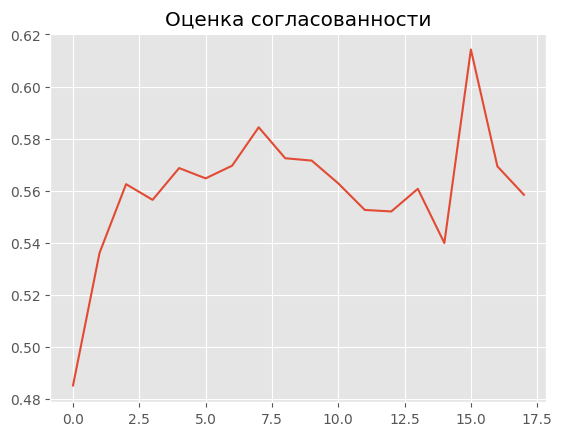

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

df.Coherence.plot(kind='line', title='Оценка согласованности');

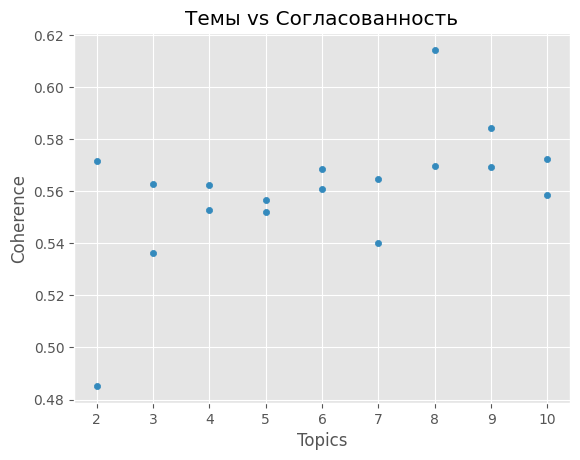

In [ ]:
df.plot.scatter(x='Topics', y='Coherence', title='Темы vs Согласованность');

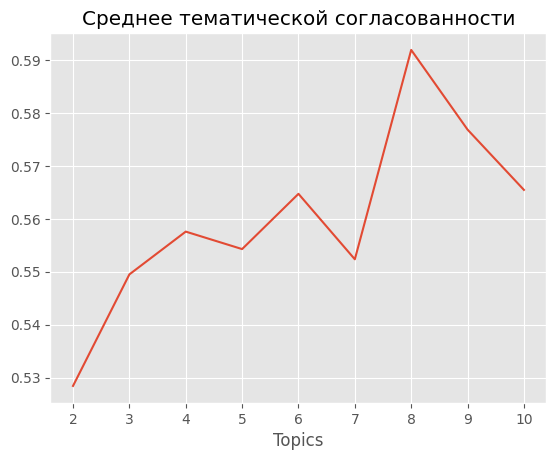

In [ ]:
df.groupby('Topics')['Coherence'].mean().plot(title='Среднее тематической согласованности')

*По итогам экспериментов лучшее количество тем  = 8*

In [ ]:
dictionary = Dictionary(data)
# Отфильтровать слова, которые встречаются менее чем в 20 документах или более чем в 40% документов.
dictionary.filter_extremes(no_below=20, no_above=0.4)
corpus = [dictionary.doc2bow(doc) for doc in data]
num_topics = 8
best_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=15)

topics = [[(term, round(wt, 3))
               for term, wt in best_model.show_topic(n)]
                   for n in range(0, best_model.num_topics)]
topics_df = pd.DataFrame([[term for term, wt in topic]
                              for topic in topics],
                         index=['Тема '+str(t) for t in range(1, best_model.num_topics+1)]).T
topics_df

,Тема 1,Тема 2,Тема 3,Тема 4,Тема 5,Тема 6,Тема 7,Тема 8
0,конкурс,район,район,желать,национальный,развитие,район,семья
1,проект,сутки,школа,праздник,карельский,предприятие,муниципальный,ребёнок
2,заявка,коронавирус,программа,коренной,язык,поддержка,глава,помощь
3,грант,ситуация,ремонт,поздравлять,культура,производство,заседание,житель
4,фонд,посёлок,строительство,здоровье,подробный,рубль,общественный,главакарелия
5,поддержка,медицинский,здание,рождение,политика,проект,совет,акция
6,участие,число,объект,карельский,общественный,федеральный,орган,ребята
7,победитель,пациент,посёлок,отмечать,организация,завод,министр,карельский
8,организация,больница,петрозаводск,память,состояться,регион,местный,группа
9,некоммерческий,находиться,житель,история,региональный,бизнес,развитие,хор


На скольких токенах и документах будет проводится обучение:

In [ ]:
print('Number of unique tokens: %d' % len(dictionary))
print('Number of documents: %d' % len(corpus))

Number of unique tokens: 4794
Number of documents: 14835


In [ ]:
# Распечатать пропорцию темы в корпусе
topics = list(best_model.get_document_topics(corpus, minimum_probability=0))
for t in range(8):
    print(f"Topic {t} proportion: {100*sum([pair[t][1] for pair in topics])/len(topics):.1f}%")

Topic 0 proportion: 12.5%
Topic 1 proportion: 12.7%
Topic 2 proportion: 19.0%
Topic 3 proportion: 11.9%
Topic 4 proportion: 13.0%
Topic 5 proportion: 13.0%
Topic 6 proportion: 13.4%
Topic 7 proportion: 4.5%


In [ ]:
# для конкретного поста
script_idx = 15
print(data[script_idx])

# Возвращает распределение тем для статьи, отсортированное по вероятности.
topics = sorted(best_model.get_document_topics(corpus[script_idx]), key=lambda t: t[1])[::-1]
topics

['четверг', 'февраль', 'лоухский', 'район', 'провести', 'совещание', 'развитие', 'район', 'встретиться', 'житель', 'культура', 'адрес', 'лоухи', 'ул', 'комментарий', 'пост', 'задавать', 'онлайнтрансляция', 'районыонлайн']


[(5, 0.55740833),
 (7, 0.19134885),
 (3, 0.12560552),
 (1, 0.10060694),
 (2, 0.006264587),
 (4, 0.0062568006),
 (0, 0.0062546954),
 (6, 0.006254225)]

In [ ]:
best_model.show_topic(5, topn=10)  # 10 самых значимых слов темы

[('житель', 0.011519055),
 ('помощь', 0.00848224),
 ('медицинский', 0.008218928),
 ('центр', 0.007939301),
 ('больница', 0.0074611795),
 ('район', 0.0068053165),
 ('провести', 0.0059850863),
 ('республиканский', 0.005327481),
 ('пункт', 0.005313015),
 ('петрозаводск', 0.0047210464)]

In [ ]:
# для одного поста
post = "сюжет первый канал посвятить 80-летие официальный открытие беломорско-балтийский канал".split()
p = [post]
dictionary = corpora.Dictionary(p)
corpus = [dictionary.doc2bow(text) for text in  p]
topics = sorted(lda_model.get_document_topics(corpus[0]), key=lambda t: t[1])[::-1]
topics

[(0, 0.37537223),
 (7, 0.32375658),
 (1, 0.23829225),
 (2, 0.012531967),
 (5, 0.012529815),
 (3, 0.0125067085),
 (4, 0.012505634),
 (6, 0.012504837)]

In [ ]:
lda_model.show_topic(0, topn=10)  # 10 самых значимых слов темы

[('желать', 0.012427873),
 ('поздравлять', 0.011909188),
 ('здоровье', 0.009676117),
 ('праздник', 0.00860304),
 ('память', 0.007467198),
 ('рождение', 0.0073134317),
 ('отмечать', 0.007255348),
 ('религиозный', 0.0065338784),
 ('победа', 0.0062767235),
 ('казачий', 0.00602246)]

In [ ]:
def get_top_topics(article_idx, min_topic_prob):

# Сортировать от наибольшей к наименьшей вероятности темы.
  topic_prob_pairs = sorted(best_model.get_document_topics(corpus[article_idx],
                                                          minimum_probability=min_topic_prob),
                            key=lambda tup: tup[1])[::-1]

  word_prob_pairs = [best_model.show_topic(pair[0]) for pair in topic_prob_pairs]
  topic_words = [[pair[0] for pair in collection] for collection in word_prob_pairs]

  data = {
      'Major Topics': topic_prob_pairs,
      'Topic Words': topic_words
  }

  return pd.DataFrame(data)
pd.set_option('max_colwidth', 600)
min_topic_prob = 0.25

article_idx = 1
print(data[article_idx])
get_top_topics(article_idx, min_topic_prob)

['апрель', 'возобновимый', 'реставрация', 'горный', 'начальник', 'здание', 'петрозаводск', 'энгельс', 'живой', 'участник', 'история', 'свидетель', 'эпоха', 'построить', 'век', 'шотландский', 'инженер', 'чарльз', 'гаскойный', 'приехать', 'карелия', 'приглашение', 'екатерина', 'развитие', 'олонецкий', 'горный', 'завод', 'реставрация', 'этап', 'бывать', 'исторический', 'здание', 'обнаружиться', 'уникальный', 'строительный', 'приём', 'элемент', 'выявиться', 'необходимость', 'дополнительный', 'потребовать', 'разработка', 'ПСД', 'поиск', 'средство', 'ставить', 'задача', 'привести', 'порядок', 'внешний', 'контур', 'кровля', 'уникальный', 'архитектурный', 'комплекс', 'предусмотреть', 'бюджет', 'республика', 'порядок', 'млн', 'рубль', 'цель', 'далее', 'федеральный', 'центр', 'решать', 'проведение', 'внутренний', 'устройство', 'экспозиция', 'национальный', 'музей', 'нашакарелия']


,Major Topics,Topic Words
0,"(2, 0.5962545)","[район, школа, программа, ремонт, строительство, здание, объект, посёлок, петрозаводск, житель]"
1,"(3, 0.26414755)","[желать, праздник, коренной, поздравлять, здоровье, рождение, карельский, отмечать, память, история]"


## Оценка человеком
Поскольку количественные показатели не полностью коррелируют с качеством, человеческое суждение по-прежнему играет большую роль в оценке тематической модели.

Мы можем попросить кого-нибудь посмотреть на тематические слова, чтобы увидеть, насколько они интерпретируемы.

Существуют также субъективные тесты, такие как вторжение слов и вторжение тем.

Внедрение слов — это взятие слов, которые принадлежат теме, введение слова из другой темы в коллекцию и проверка того, может ли человек легко определить слово-нарушитель. Чем легче обнаружить слово-нарушитель, тем лучше сформирована тема. Например, какое слово не принадлежит этой теме?

{apple, lemon, tomato, horse, grape}

Мы также можем визуализировать их с помощью облаков слов.

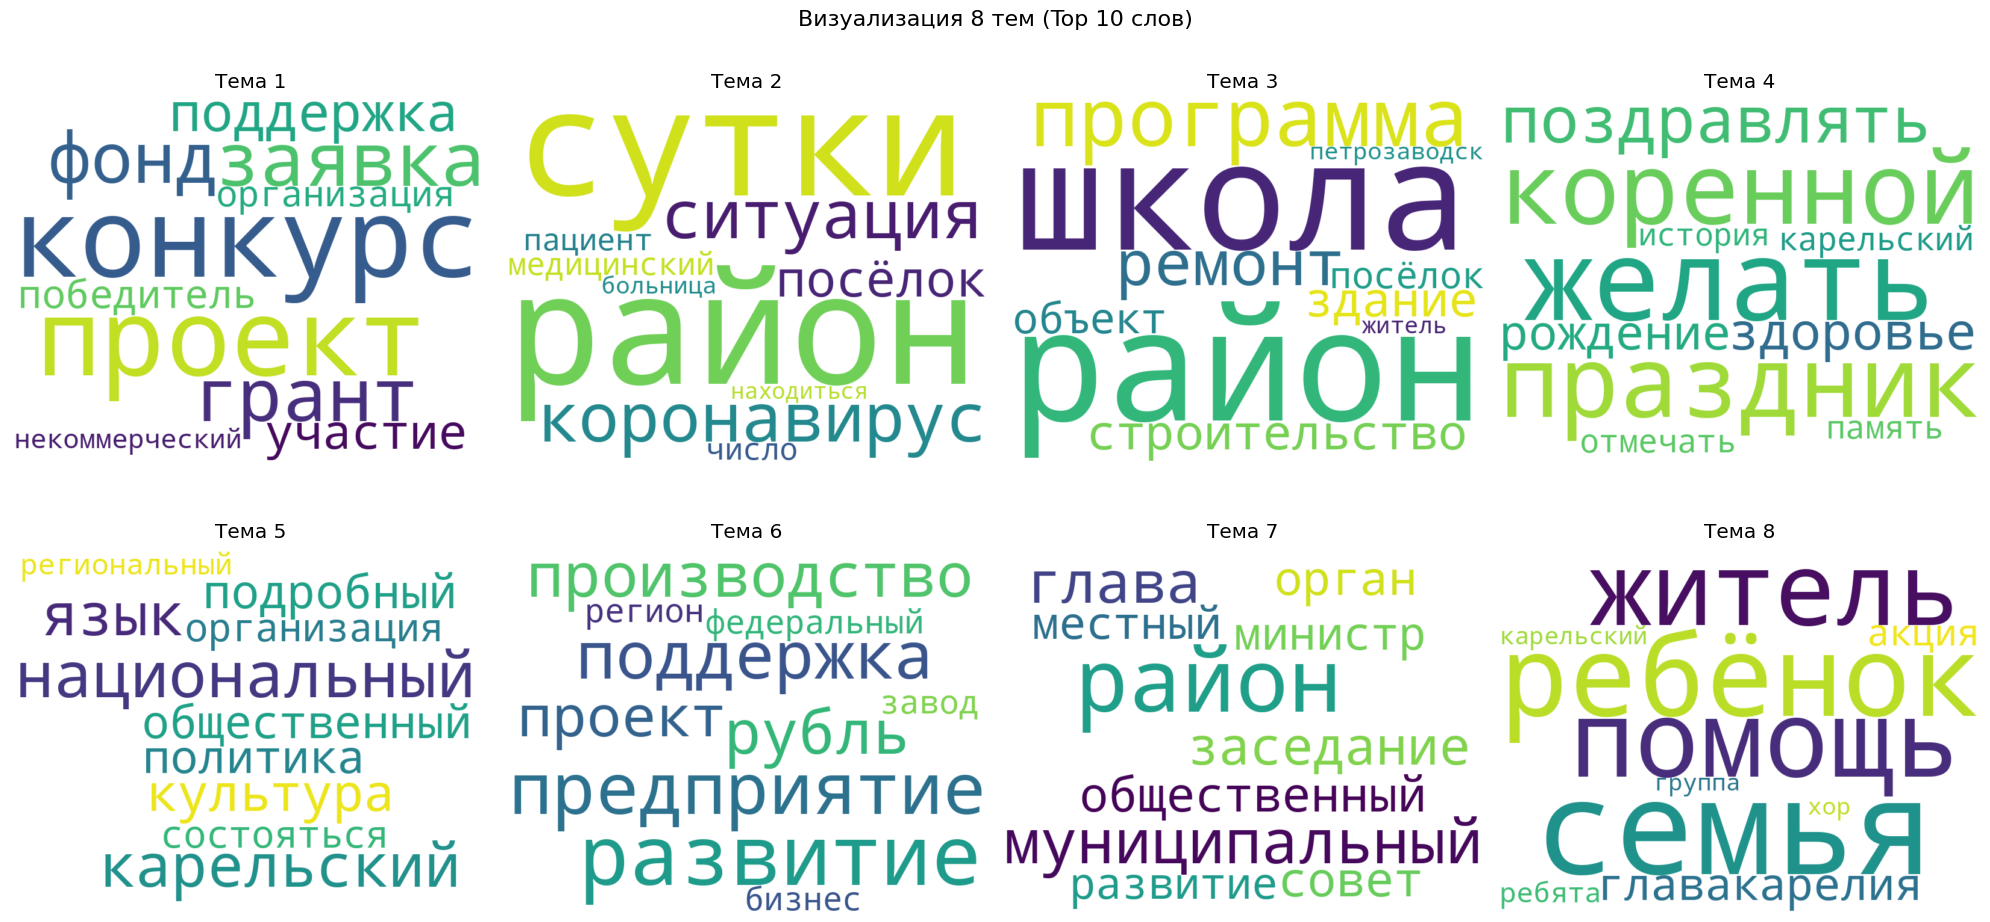

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def visualize_topics_8(model, max_words=15):
    """
    Визуализирует все 8 тем модели LDA в виде облаков слов

    Параметры:
    model - обученная LDA модель
    max_words - максимальное количество слов для отображения в каждом облаке
    """
    # Настройки облака слов
    wordcloud = WordCloud(
        background_color='white',
        max_words=max_words,
        width=800,
        height=600,
        prefer_horizontal=1.0,
        colormap='viridis',
        contour_width=1
    )

    # Создаем сетку 2x4 для 8 тем
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Визуализация 8 тем (Top {} слов)'.format(max_words), fontsize=16)
    plt.subplots_adjust(wspace=0.1, hspace=0.2)

    for topic_num in range(8):
        ax = axes[topic_num//4, topic_num%4]  # Распределение по сетке 2x4

        # Получаем слова и их веса для темы
        topic_words = dict(model.show_topic(topic_num, topn=max_words))

        # Генерируем и отображаем облако слов
        wordcloud.generate_from_frequencies(topic_words)
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title('Тема {}'.format(topic_num+1), pad=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Пример использования
visualize_topics_8(best_model, max_words=10)

# Интерактивная визуализация тематических моделей


*   Распределение тем в документах

*   Ключевые слова каждой темы

*   Сходство между темами (через расстояния на 2D-плоскости)




*Главный график (Карта расстояний между темами)*

Каждый пузырь — одна тема

Размер пузыря — распространённость темы в корпусе

Расстояние между пузырями — семантическая близость тем

Оси — линейные комбинации слов (PC1/PC2), уменьшенные до 2D через PCA


*Top-30 слов для выбранной темы*

Показывает наиболее релевантные слова темы


Relevance (λ=0.6 по умолчанию) — баланс между:

Внутри-тематической частотой (term frequency within topic)

Уникальностью для темы (exclusivity to topic)

Чем больше λ, тем более частотные слова отображаются, чем меньше, тем более уникальные.




In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

Визуализация распределения вероятностей топ-100 слов для каждой темы LDA-модели в виде кривых зависимостей весов слов от их ранга. График позволяет сравнить темы по крутизне спада вероятностей и степени концентрации вокруг ключевых слов.

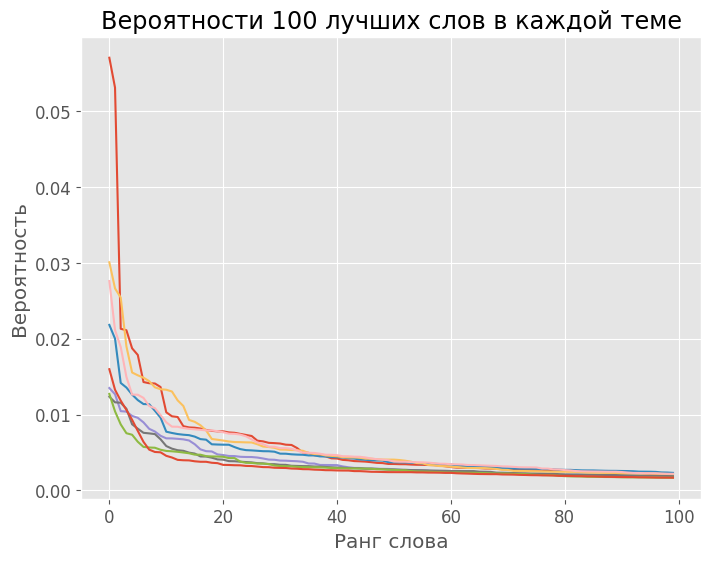

In [ ]:
# change default figure and font size
plt.rcParams['figure.figsize'] = 8, 6
plt.rcParams['font.size'] = 12

# 100 лучших слов по весу в каждой теме
top_n_words = 100
topics = best_model.show_topics(
    num_topics = num_topics, num_words = top_n_words, formatted = False)

for _, infos in topics:
    probs = [prob for _, prob in infos]
    plt.plot(range(top_n_words), probs)

plt.xlabel('Ранг слова')
plt.ylabel('Вероятность')
plt.title('Вероятности 100 лучших слов в каждой теме')
plt.show()

In [ ]:
# Создаем DataFrame для хранения результатов
sent_topics_df = pd.DataFrame(columns=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords', 'Text'])

# Обрабатываем каждый документ в корпусе
for i, doc in enumerate(corpus):  # Используем corpus вместо lda_model[corpus]
    # Получаем распределение тем для документа
    doc_topics = lda_model.get_document_topics(doc)  # Это правильный способ получить темы документа

    # Сортируем темы по убыванию вероятности
    doc_topics_sorted = sorted(doc_topics, key=lambda x: x[1], reverse=True)

    if doc_topics_sorted:  # Проверяем, что есть темы
        # Берем доминирующую тему
        dominant_topic_num, dominant_topic_prob = doc_topics_sorted[0]

        # Получаем ключевые слова темы
        topic_keywords = ", ".join([word for word, prob in lda_model.show_topic(dominant_topic_num)])

        # Добавляем информацию в DataFrame
        sent_topics_df.loc[i] = [
            int(dominant_topic_num),
            round(dominant_topic_prob, 4),
            topic_keywords,
            " ".join(data[i])  # Объединяем токены в текст
        ]


In [ ]:
sent_topics_df.head(15)

,Dominant_Topic,Perc_Contribution,Topic_Keywords,Text
0,1,0.3585,"район, проект, строительство, программа, житель, объект, территория, поселение, посёлок, ремонт",добрый быстро расти лобановский мост основный металлоконструкция установить смонтировать основной блок поперечный балка завершаться сварочный несмотря снег низкий температура специалист балтмостстрой ударный темп нашакарелия
1,1,0.5649,"район, проект, строительство, программа, житель, объект, территория, поселение, посёлок, ремонт",апрель возобновимый реставрация горный начальник здание петрозаводск энгельс живой участник история свидетель эпоха построить век шотландский инженер чарльз гаскойный приехать карелия приглашение екатерина развитие олонецкий горный завод реставрация этап бывать исторический здание обнаружиться уникальный строительный приём элемент выявиться необходимость дополнительный потребовать разработка ПСД поиск средство ставить задача привести порядок внешний контур кровля уникальный архитектурный комплекс предусмотреть бюджет республика порядок млн рубль цель далее федеральный центр решать проведен...
2,0,0.6058,"желать, поздравлять, здоровье, праздник, память, рождение, отмечать, религиозный, победа, казачий",больший удовольствие старт чемпионат орган безопасность федеральный округ фок динамо состояться соревнование течение неделя команда участник состязаться лыжный гонка плавание стрельба двоеборье петрозаводск принимать спартакиада посвятить победа великий отечественный символичный общество динамо великий отечественный активно включиться подготовка население оборона спортивный секция превратиться проведение тренировочный сбор член общество помогать готовить военный отряд июнь спортобъект динамо передать военный обучение солдат ребята стража безопасность желать участник удача пусть победить си...
3,6,0.4861,"язык, карельский, культура, вепсский, фестиваль, народный, национальный, финский, творческий, традиция",история сумка аксессуар ручной красота уникальность наверняка многие оценить история семья увлечь творчество кондопожанка шенина мама четверо ребёнок открыть семейный мастерская старинный деревня многий знакомый совдозеро корень семья история деревня сохраняться продолжаться творчество поколение ксения мама дочь валерий серафим любовь родный край передавать творчество использовать создание сумка рюкзак изображение карельский ягода цвет растение открыть мастерица помочь благодаря соцконтракт ксения приобрести оборудование расходный материал начинающий предприниматель финансовый поддержка от...
4,1,0.4765,"район, проект, строительство, программа, житель, объект, территория, поселение, посёлок, ремонт",поделиться итог рабочий поездка север карелия неделя кемь калевала лоухи беломорск ключевой безусловно встреча земляк актуальный повестка район оставаться медицина ЖКХ ремонт образовательный учреждение расселение аварийный жильё задать встреча отработать коллега доложить поручение число пример ремонт городской стадион кемь возможность продление автобусный маршрут костомукша боровой юшкозеро райцентр организация хирургия чупа решение кадровый проблема медик беломорск расселение аварийный жильё задача номер район сформировать общественный комиссия определять первоочерёдность расселение авари...
5,1,0.5458,"район, проект, строительство, программа, житель, объект, территория, поселение, посёлок, ремонт",беломорск завершать серия встреча житель северный район живой диалог обсудить развитие округ коротко медицина установить пушной модульный ФАП капитально отремонтировать фап посёлок колежма машезеро решать кадровый проблема договор ЦРБ обучаться целевиковый жильё утверждение федеральный программа предстоять расселить округ квартира проживать тыс сложный задача отметить единственный район строительство переселение готовый проект пройти экспертиза положительный заключение квартира строить строительный образование капитально отремонтировать школа беломорск приступить ремонт школа план ставить ...
6,0,0.8973,"желать, поздравлять, здоровье, праздник, памят

In [ ]:
# Получаем статистику по темам
topic_counts = sent_topics_df['Dominant_Topic'].value_counts().sort_index()  # Сортировка по номерам тем
topic_contribution = round(topic_counts / topic_counts.sum(), 4) * 100  # Проценты с округлением

# Убедимся, что все 8 тем присутствуют (даже если для некоторых 0 документов)
all_topics = range(8)  # Для 8 тем (0-7)
topic_counts = topic_counts.reindex(all_topics, fill_value=0)
topic_contribution = topic_contribution.reindex(all_topics, fill_value=0)

# Получаем уникальные пары "Тема-Ключевые слова"
topic_num_keywords = (
    sent_topics_df[['Dominant_Topic', 'Topic_Keywords']]
    .drop_duplicates()
    .set_index('Dominant_Topic')
    .reindex(all_topics)  # Добавляем все темы, даже если они не встретились
)

# Собираем финальную таблицу
df_dominant_topics = pd.concat([
    topic_num_keywords,
    topic_counts.rename('Num_Documents'),
    topic_contribution.rename('Perc_Documents')
], axis=1).reset_index()

# Переименовываем колонки
df_dominant_topics.columns = [
    'Topic-ID',
    'Keywords',
    'Documents Count',
    'Documents %'
]

# Заполняем пропущенные ключевые слова (если тема не встретилась)
df_dominant_topics['Keywords'] = df_dominant_topics['Keywords'].fillna(
    df_dominant_topics['Topic-ID'].apply(
        lambda x: ", ".join([w for w, _ in lda_model.show_topic(x)])
    )
)

# Сортируем по номеру темы (по возрастанию)
df_dominant_topics = df_dominant_topics.sort_values('Topic-ID')

# Форматируем проценты
df_dominant_topics['Documents %'] = df_dominant_topics['Documents %'].apply(lambda x: f"{x:.1f}%")

# Выводим все 8 тем, отсортированные по ID
print(f"\nРаспределение {len(df_dominant_topics)} тем (отсортировано по номеру темы):")
display(df_dominant_topics)


Распределение 8 тем (отсортировано по номеру темы):


,Topic-ID,Keywords,Documents Count,Documents %
0,0,"желать, поздравлять, здоровье, праздник, память, рождение, отмечать, религиозный, победа, казачий",2987,20.1%
1,1,"район, проект, строительство, программа, житель, объект, территория, поселение, посёлок, ремонт",1703,11.5%
2,2,"район, сутки, посёлок, ситуация, число, находиться, петрозаводск, пациент, пневмония, население",433,2.9%
3,3,"развитие, коренной, рубль, российский, федеральный, поддержка, проект, правительство, бюджет, федерация",1132,7.6%
4,4,"национальный, организация, общественный, проект, конкурс, политика, подробный, региональный, участие, министерство",2555,17.2%
5,5,"предприятие, житель, производство, помощь, мера, завод, компания, гражданин, семья, продукция",2558,17.2%
6,6,"язык, карельский, культура, вепсский, фестиваль, народный, национальный, финский, творческий, традиция",2302,15.5%
7,7,"школа, детский, ребёнок, центр, сад, медицинский, здание, больница, учреждение, республиканский",1165,7.8%


#Запросы на схожесть

Демонстрирует поиск похожих документов в корпусе.

В Gensim есть модуль сходства, который может построить индекс для заданного набора документов. Здесь мы используем Matrix Similarity, который вычисляет косинусное сходство по всему корпусу и сохраняет их в индексе.

Предположим, что пользователь ввел запрос «общественный региональный проект» . Мы хотели бы отсортировать наши корпусные документы в порядке убывания релевантности этому запросу. В отличие от современных поисковых систем, здесь мы концентрируемся только на одном аспекте возможных сходств — на очевидной семантической связанности их текстов (слов). Никаких гиперссылок, никаких случайных статических рангов, только семантическое расширение по булевому совпадению ключевых слов:

In [ ]:
from gensim import models
lsi = models.LsiModel(corpus, id2word=dictionary, num_topics=8)
doc = "общественный региональный проект"
vec_bow = dictionary.doc2bow(doc.lower().split())
vec_lsi = lsi[vec_bow]
print(vec_lsi)

/usr/local/lib/python3.11/dist-packages/gensim/models/lsimodel.py:963: DeprecationWarning: `scipy.sparse.sparsetools.csc_matvecs` is deprecated along with the `scipy.sparse.sparsetools` namespace. `scipy.sparse.sparsetools.csc_matvecs` will be removed in SciPy 1.14.0, and the `scipy.sparse.sparsetools` namespace will be removed in SciPy 2.0.0.
  sparsetools.csc_matvecs(


[(0, 0.39702975241465815), (1, 0.3295734912456809), (2, -0.16941506468683165), (3, 0.5313936795704692), (4, 0.03491509396546982), (5, -0.20690765444930123), (6, -0.027473110207539078), (7, 0.45393679887076777)]


In [ ]:
from gensim import similarities
index = similarities.MatrixSimilarity(lsi[corpus])

In [ ]:
sims = index[vec_lsi] # выполнить запрос на сходство по корпусу
print(list(enumerate(sims)))  # print (номер_документа, сходство_документа) 2-кортеж

[(0, -0.14297879), (1, 0.2799279), (2, 0.22945075), (3, -0.03650382), (4, 0.031271502), (5, 0.28658986), (6, -0.028001964), (7, -0.007441297), (8, 0.009953082), (9, 0.06705657), (10, 0.025758147), (11, -0.04468772), (12, 0.29948732), (13, 0.17625183), (14, -0.012483686), (15, 0.11162728), (16, 0.33397618), (17, 0.18286277), (18, 0.07672526), (19, -0.055235222), (20, 0.32782653), (21, 0.10541579), (22, 0.28864986), (23, 0.013503298), (24, -0.07239373), (25, 0.47278702), (26, 0.21947992), (27, -0.012376249), (28, 0.2983717), (29, -0.072270185), (30, 0.32944083), (31, -0.00020319223), (32, 0.1553184), (33, 0.26463395), (34, 0.3268408), (35, 0.45984402), (36, 0.65859264), (37, 0.06375633), (38, -0.06697157), (39, 0.23675624), (40, -0.0441252), (41, -0.022047803), (42, 0.05834207), (43, 0.33005846), (44, 0.21078038), (45, 0.06349978), (46, -0.0075527728), (47, 0.24839728), (48, 0.4243028), (49, 0.12766913), (50, 0.019165158), (51, 0.1864044), (52, -0.24389702), (53, 0.78100044), (54, 0.2359

In [ ]:
sims = sorted(enumerate(sims), key=lambda item: -item[1])
for doc_position, doc_score in sims:
    print(doc_score, data[doc_position])

Streaming output truncated to the last 5000 lines.
0.06542131 ['соглашение', 'группа', 'компания', 'медскан', 'входящий', 'десятка', 'крупный', 'негосударственный', 'клиника', 'подписать', 'петербургский', 'международный', 'экономический', 'форум', 'глава', 'карелия', 'артур', 'парфенчик', 'результат', 'совместный', 'медицинский', 'центр', 'петрозаводск', 'клиника', 'появиться', 'сотня', 'рабочий', 'житель', 'карелия', 'смочь', 'наблюдаться', 'ведущий', 'специалист', 'федеральный', 'международный', 'уровень']
0.06536375 ['видео', 'прислать', 'земляк', 'олег', 'куйкина', 'позывной', 'фонарик', 'познакомиться', 'позиция', 'тероборона', 'посещать', 'подразделение', 'войнов', 'накануне', 'парень', 'поделиться', 'кадр', 'снять', 'проезжать', 'старобельск', 'стоить', 'памятник', 'великий', 'отечественный', 'боевой', 'танк', 'вновь', 'возвышаться', 'триколор', 'присягать', 'родина', 'пройти', 'упавший', 'российский', 'флаг']
0.06536034 ['продолжать', 'совершенствовать', 'трехуровневый', 'сист

In [ ]:
lda_index = similarities.MatrixSimilarity(best_model[corpus], num_features=len(dictionary))

In [ ]:
def get_similar_articles(index, model, article_bow, top_n=5, first_m_words=300):
# model[article_bow] извлекает распределение тем для BOW.
# index[model[article_bow] сравнивает распределение тем для BOW с ранее вычисленным индексом сходства.
  similar_docs = index[model[article_bow]]
  top_n_docs = sorted(enumerate(similar_docs), key=lambda item: -item[1])[1:top_n+1]

# Верните список кортежей, где каждый кортеж: (идентификатор статьи, показатель схожести, first_m_words статьи)
  return list(map(lambda entry: (entry[0], entry[1], data[entry[0]][:first_m_words]), top_n_docs))

article_idx = 0
print(data[article_idx][:snippet_length], '\n')
get_similar_articles(lda_index,  best_model, corpus[article_idx])

['добрый', 'быстро', 'расти', 'лобановский', 'мост', 'основный', 'металлоконструкция', 'установить', 'смонтировать', 'основной', 'блок', 'поперечный', 'балка', 'завершаться', 'сварочный', 'несмотря', 'снег', 'низкий', 'температура', 'специалист', 'балтмостстрой', 'ударный', 'темп', 'нашакарелия'] 



[(750,
  0.9999781,
  ['суоярвский',
   'шоссе',
   'ликвидировать',
   'подтопление',
   'участок',
   'вблизи',
   'фок',
   'динамо',
   'снизиться',
   'продолжать',
   'уходить',
   'мобильный',
   'бригада',
   'перекачивать',
   'привлечь',
   'техника',
   'компания',
   'КСМ',
   'устранить',
   'подтопление',
   'помогать',
   'МЧС',
   'задача',
   'допустить',
   'подтопление',
   'течение',
   'неглинка',
   'поручение',
   'прочистить',
   'русло',
   'река',
   'разлив',
   'касаться',
   'фок',
   'периметр',
   'здание',
   'проложить',
   'мешок',
   'песок',
   'продолжить',
   'откачивать',
   'непосредственно',
   'территория',
   'спорткомплекс',
   'поручение',
   'александр',
   'чепик',
   'выехать',
   'контролировать',
   'ситуация']),
 (6874,
  0.9997969,
  ['ключ',
   'благоустроенный',
   'квартира',
   'семья',
   'посёлок',
   'матрос',
   'житель',
   'принимать',
   'участие',
   'приёмка',
   'жильё',
   'высказывать',
   'замечание',
   'предложение'